<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-I/blob/main/sistemas_de_linea_de_espera_con_dos_servidores_en_serie_y_paralelo_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SISTEMAS MEDIANTE EVENTOS DISCRETOS

##Sistemas de línea de espera con dos servidores en serie

**Nombre**: Karla Michelle Soriano Sánchez  

**Instrucción**: Programar en Jupyter Notebook el seudocódigo propuesto por Sheldon Ross para un sistema de línea de espera con dos servidores en serie.

Como prueba utilizar:
$
\lambda = 4
$
y
$
\mu = 6.
$

Comentar y documentar el código. Analizar los resultados obtenidos mediante simulación.

**Objetivo**: Implementar mediante simulación por eventos discretos un sistema de línea de espera con dos servidores en serie siguiendo el algoritmo propuesto por Sheldon Ross.


###Fundamento teórico

**Sistema de línea de espera con dos servidores en serie**

En este sistema cada cliente debe recibir servicio en dos etapas consecutivas.

Primero es atendido por el servidor 1, después pasa al servidor 2 y finalmente abandona el sistema.

El esquema general es

$$
\text{Llegadas}
\rightarrow
\text{Servidor 1}
\rightarrow
\text{Servidor 2}
\rightarrow
\text{Salida}.
$$

Este tipo de sistema también se conoce como cola en tándem o secuencial.

**Distribuciones utilizadas**

Las llegadas siguen un proceso de Poisson con tasa
$
\lambda,
$
por lo que los tiempos entre llegadas se modelan mediante una distribución exponencial:
$
T \sim Exp(\lambda).
$

Los tiempos de servicio de ambos servidores también se consideran exponenciales con parámetro
$
\mu.
$

**Variable de tiempo**

La simulación se desarrolla mediante una variable de tiempo
$
t,
$
la cual representa el instante actual del sistema.

Cada vez que ocurre un evento, el reloj de simulación avanza hasta el tiempo asociado a dicho evento.

**Estado del sistema**

Se define el estado del sistema mediante el par ordenado

$$
(n_1,n_2),
$$

donde:

- $n_1$ representa el número de clientes asociados al servidor 1.
- $n_2$ representa el número de clientes asociados al servidor 2.

Estos valores incluyen tanto a los clientes que están siendo atendidos como a aquellos que esperan en la fila correspondiente.

**Variables de conteo**

$N_A$ : Número de llegadas registradas hasta el instante $t$.

$N_D$ :  Número de clientes que han abandonado completamente el sistema hasta el instante $t$.

**Variables de salida**

Para cada cliente se almacenarán los instantes más importantes de su recorrido dentro del sistema.
Dado $n \geq 1$

$
A_1(n)
$
 : Hora de llegada del cliente $n$ al sistema.

$
A_2(n)
$
 : Hora de llegada del cliente $n$ al servidor 2.

$
D(n)
$
 : Hora de salida del cliente $n$ del sistema.

**Lista de eventos**

La simulación se basa en una lista de eventos formada por

$$
(t_A,t_1,t_2),
$$

donde:

- $t_A$ es el instante (hora)  de la próxima llegada.
- $t_1$ es el instante en que finalizará el servicio actualmente en el servidor 1.
- $t_2$ es el instante en que finalizará el servicio actualmente en el servidor 2.

En cada iteración se selecciona el menor de estos tiempos para determinar el siguiente evento.

**Eventos posibles**

De acuerdo con el algoritmo de Ross, pueden ocurrir tres tipos de eventos.

- Evento 1: Llegada de un cliente.
 Ocurre cuando

$$
t_A=\min(t_A,t_1,t_2).
$$
En este caso un nuevo cliente entra al sistema y se actualizan las variables correspondientes.

- Evento 2: Salida del servidor 1. Ocurre cuando

$$
t_1<t_A
$$

y

$$
t_1\le t_2.
$$
El cliente termina su servicio en el servidor 1 y pasa al servidor 2.


- Evento 3: Salida del servidor 2. Ocurre cuando

$$
t_2<t_A
$$

y

$$
t_2<t_1.
$$

El cliente concluye su servicio en el servidor 2 y abandona el sistema.

**Implementación del algoritmo**

*Generación de tiempos aleatorios*


Para implementar el algoritmo de Ross se utilizarán funciones auxiliares que permitan generar:

- tiempos entre llegadas;
- tiempos de servicio del servidor 1;
- tiempos de servicio del servidor 2.

Estas funciones serán utilizadas posteriormente en la actualización de los eventos del sistema.

In [134]:
import numpy as np
import random as r
from tabulate import tabulate
import matplotlib.pyplot as plt

In [135]:
# Generar tiempo entre llegadas

def generar_llegada(lamda):

    # Generar variable exponencial
    return np.random.exponential(1 / lamda)

In [136]:
# Generar tiempo de servicio

def generar_servicio(mu):

    # Generar variable exponencial
    return np.random.exponential(1 / mu)

*Inicialización del sistema*

La simulación comienza con que  no existen clientes dentro del sistema, por lo que

$
N_A=N_D=0
$
y
$
(n_1,n_2)=(0,0)
$

Posteriormente se genera el primer tiempo entre llegadas
$
T_0
$
y se construye la lista inicial de eventos

$$
t_A=T_0,
\qquad
t_1=t_2=\infty.
$$

Además, se crean las estructuras donde se almacenarán las horas de llegada y salida de cada cliente.

In [137]:
# ==========================================================
# Inicialización del sistema
# ==========================================================

def inicializar_sistema(lamda):

    # Tiempo actual
    t = 0

    # Variables de conteo
    NA = 0
    ND = 0

    # Estado del sistema
    n1 = 0
    n2 = 0

    # Primera llegada
    tA = generar_llegada(lamda)

    # No existen clientes en servicio
    t1 = np.inf
    t2 = np.inf

    # Estructuras para almacenar resultados
    A1 = []
    A2 = []
    D = []

    return t, NA, ND, n1, n2, tA, t1, t2, A1, A2, D

*Caso 1: Llegada de un cliente*

Este evento ocurre cuando

$$
t_A=\min(t_A,t_1,t_2).
$$

En este caso el reloj de simulación avanza hasta el instante
$
t=t_A.
$

Posteriormente se actualizan las variables de conteo y de estado:

$
N_A=N_A+1
\quad $ y
$\quad n_1=n_1+1.
$

Posteriormente se programa la siguiente llegada al sistema
Si el servidor 1 estaba vacío, se genera un tiempo de servicio y se programa la correspondiente salida.

Finalmente se registra

$$
A_1(N_A)=t.
$$



In [138]:
# ==========================================================
# Caso 1: Llegada al sistema
# ==========================================================

def evento_llegada( t, NA, n1, tA, t1, A1, lamda, mu):

    # Avanzar reloj al instante de llegada
    t = tA

    # Actualizar contadores
    NA += 1
    n1 += 1

    # Registrar llegada al sistema
    A1.append(t)

    # Programar siguiente llegada
    tA = t + generar_llegada(lamda)

    # Si el servidor 1 estaba vacío,
    # el cliente inicia servicio inmediatamente
    if n1 == 1:
        t1 = t + generar_servicio(mu)

    return t, NA, n1, tA, t1, A1

*Caso 2: Salida del servidor 1*

Esto sucede cuando

$
t_1<t_A \quad
$
y
$
\quad t_1\le t_2.
$

En este instante el cliente abandona el servidor 1 y pasa al servidor 2, por lo que:

$
n_1=n_1-1 \quad
$
y
$
\quad n_2=n_2+1
$

Si aún existen clientes asociados al servidor 1, se programa la siguiente salida de dicho servidor.

Si el servidor 2 estaba vacío, se genera un tiempo de servicio y se programa su correspondiente salida.

Finalmente se registra
$
A_2(N_A-n_1)=t
$

In [139]:
# Caso 2: Salida del servidor 1

def salida_servidor_1( t, NA, n1, n2, t1, t2, A2, mu ):

    # Avanzar reloj
    t = t1

    # Cliente abandona servidor 1
    n1 -= 1
    n2 += 1

    # Actualizar servidor 1
    if n1 == 0:
        t1 = np.inf
    else:
        t1 = t + generar_servicio(mu)

    # Actualizar servidor 2
    if n2 == 1:
        t2 = t + generar_servicio(mu)

    # Registrar llegada al servidor 2
    cliente = NA - n1
    A2.append(t)

    return t, n1, n2, t1, t2, A2

*Caso 3: Salida del servidor 2*

Esto sucede cuando

$
t_2<t_A
\quad $
y
$\quad
t_2<t_1
$


Siguiendo el algoritmo de Ross, el cliente abandona el sistema, por lo que

$
N_D=N_D+1 \quad
$
y
$ \quad
n_2=n_2-1.
$

Si aún existen clientes asociados al servidor 2, se genera un nuevo tiempo de servicio y se programa la siguiente salida.

Finalmente se registra

$$
D(N_D)=t.
$$

In [140]:
# Caso 3: Salida del servidor 2

def salida_servidor_2( t, ND, n2, t2, D, mu ):

    # Avanzar reloj
    t = t2

    # Actualizar variables del sistema
    ND += 1
    n2 -= 1

    # Registrar salida del sistema
    D.append(t)

    # Actualizar servidor 2
    if n2 == 0:
        t2 = np.inf
    else:
        t2 = t + generar_servicio(mu)

    return t, ND, n2, t2, D

**Función principal de simulación**


Una vez definidas las funciones correspondientes a cada evento, se construye la función principal que ejecuta la simulación.

En cada iteración se identifica el menor elemento de la lista de eventos y se aplica la actualización correspondiente siguiendo el algoritmo de Ross.



In [141]:
# ==========================================================
# Función principal de simulación
# ==========================================================

def simular_dos_servidores_serie(lamda, mu, clientes):

    # ------------------------------------------------------
    # Inicialización del sistema
    # ------------------------------------------------------

    (t, NA, ND,
     n1, n2,
     tA, t1, t2,
     A1, A2, D) = inicializar_sistema(lamda)

    # ------------------------------------------------------
    # Historial del sistema
    # ------------------------------------------------------

    tiempos = [t]
    estado_n1 = [n1]
    estado_n2 = [n2]

    # ------------------------------------------------------
    # Ciclo principal de simulación
    # ------------------------------------------------------

    while ND < clientes:

        # ==================================================
        # Caso 1: Llegada al sistema
        # ==================================================

        if tA <= t1 and tA <= t2:

            t, NA, n1, tA, t1, A1 = evento_llegada(
                t, NA, n1,
                tA, t1,
                A1,
                lamda, mu
            )

        # ==================================================
        # Caso 2: Salida del servidor 1
        # ==================================================

        elif t1 < tA and t1 <= t2:

            t, n1, n2, t1, t2, A2 = salida_servidor_1(
                t, NA,
                n1, n2,
                t1, t2,
                A2,
                mu
            )

        # ==================================================
        # Caso 3: Salida del servidor 2
        # ==================================================

        else:

            t, ND, n2, t2, D = salida_servidor_2(
                t, ND,
                n2,
                t2,
                D,
                mu
            )

        # --------------------------------------------------
        # Guardar evolución del sistema
        # --------------------------------------------------

        tiempos.append(t)
        estado_n1.append(n1)
        estado_n2.append(n2)

    # ------------------------------------------------------
    # Resultados
    # ------------------------------------------------------

    return {
        "A1": A1,
        "A2": A2,
        "D": D,
        "tiempos": tiempos,
        "n1": estado_n1,
        "n2": estado_n2
    }

**Ejecución de la simulación**

Una vez implementado el algoritmo de Ross, se ejecuta la simulación utilizando los parámetros propuestos.

Como caso de prueba se consideran

$$
\lambda = 4
$$

y

$$
\mu = 6.
$$

Además, se fija un número de clientes a simular. A partir de la información generada se analizará el comportamiento del sistema y posteriormente se compararán los resultados con la solución analítica.

In [142]:
# Parámetros de la simulación

lamda = 4
mu = 6

clientes = 1000

# Semilla para reproducibilidad
np.random.seed(123)

# Ejecutar simulación
resultado = simular_dos_servidores_serie(
    lamda,
    mu,
    clientes
)

In [143]:
print("Llegadas al sistema:", len(resultado["A1"]))
print("Llegadas al servidor 2:", len(resultado["A2"]))
print("Salidas:", len(resultado["D"]))

Llegadas al sistema: 1002
Llegadas al servidor 2: 1002
Salidas: 1000


Los tiempos obtenidos son consistentes con la lógica del sistema en serie.

Las llegadas al servidor 2 ocurren después de las llegadas al sistema y las salidas se producen después del servicio en ambos servidores.

**Estadísticos descriptivos**

Una vez obtenidos los tiempos de llegada y salida de cada cliente, se calculan los tiempos asociados a cada etapa del sistema.

En particular, se consideran:

- Tiempo en el servidor 1.
- Tiempo en el servidor 2.
- Tiempo total en el sistema.

Para cada uno de estos tiempos se calculan la media, desviación estándar, valor mínimo y valor máximo.

Estas medidas permiten describir el comportamiento general del sistema y facilitan la interpretación de los resultados obtenidos mediante simulación.

In [145]:
# Tiempo en servidor 1
T1 = np.array(resultado["A2"]) - np.array(resultado["A1"])

# Tiempo en servidor 2
T2 = np.array(resultado["D"]) - np.array(resultado["A2"])

# Tiempo total en el sistema
T_total = np.array(resultado["D"]) - np.array(resultado["A1"])

# Función para calcular estadísticas

def resumen(datos):
  return {
        "Media": np.mean(datos),
        "Desv. estándar": np.std(datos),
        "Mínimo": np.min(datos),
        "Máximo": np.max(datos) }

print("Servidor 1")
print(resumen(T1))

print("\nServidor 2")
print(resumen(T2))

print("\nTiempo total en el sistema")
print(resumen(T_total))



ValueError: operands could not be broadcast together with shapes (1000,) (1002,) 

**Comparación de tiempos en los servidores**

La siguiente gráfica muestra el tiempo que cada cliente permanece asociado a cada servidor.

Se representan simultáneamente:

- $T_1$: tiempo desde que el cliente llega al sistema hasta que finaliza su atención en el servidor 1.
- $T_2$: tiempo desde que el cliente llega al servidor 2 hasta que abandona dicho servidor.

La comparación permite identificar diferencias en los tiempos observados en cada etapa del sistema y visualizar la variabilidad generada por los tiempos aleatorios de servicio.

ValueError: x and y must have same first dimension, but have shapes (1002,) and (1000,)

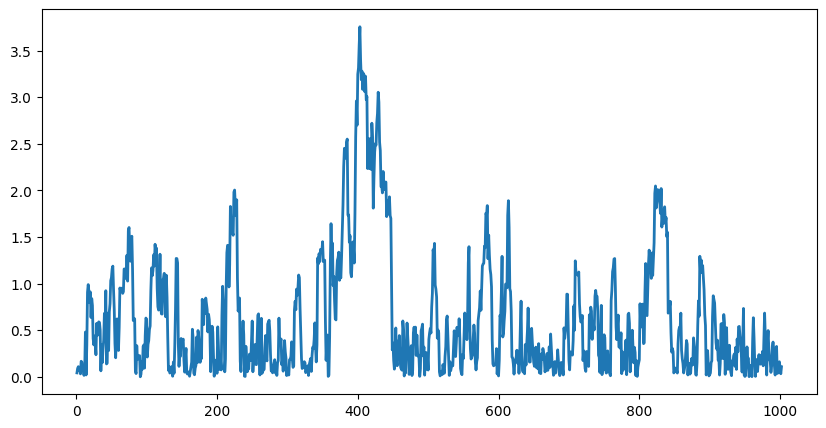

In [146]:
# Gráfica de tiempos en cada servidor

clientes = np.arange(1, len(T1) + 1)

plt.figure(figsize=(10,5))
plt.plot(clientes, T1, label="Servidor 1", linewidth=2)
plt.plot(clientes, T2, label="Servidor 2", linewidth=2)
plt.xlabel("Cliente")
plt.ylabel("Tiempo")
plt.title("Tiempo observado en cada servidor")
plt.legend()
plt.grid(True)
plt.show()